# Projeto Sprint 9 — Tomando Decisões de Negócios Baseadas em Dados


### Contexto

Uma loja online quer aumentar sua receita e está avaliando **9 hipóteses** levantadas pelo time de marketing.
Antes de executar um teste A/B, precisamos **priorizar** quais hipóteses têm mais chances de gerar resultado com o menor esforço possível.


### Dados disponíveis

| Arquivo | Conteúdo |
|---------|----------|
| `hypotheses_us.csv` | 9 hipóteses com pontuações de Reach, Impact, Confidence e Effort |
| `orders_us.csv` | Pedidos realizados durante o teste A/B (grupos A e B) |
| `visits_us.csv` | Visitas diárias por grupo (A e B) durante o teste |

In [1]:
import pandas as pd
from scipy import stats as st
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Carregando os dados
hipoteses = pd.read_csv('hypotheses_us.csv', sep=';')
pedidos   = pd.read_csv('orders_us.csv')
visitas   = pd.read_csv('visits_us.csv')

print('--------------- Hipóteses ---------------')

hipoteses


--------------- Hipóteses ---------------


,Hypothesis,Reach,Impact,Confidence,Effort
0,Add two new channels for attracting traffic. T...,3,10,8,6
1,Launch your own delivery service. This will sh...,2,5,4,10
2,Add product recommendation blocks to the store...,8,3,7,3
3,Change the category structure. This will incre...,8,3,3,8
4,Change the background color on the main page. ...,3,1,1,1
5,Add a customer review page. This will increase...,3,2,2,3
6,Show banners with current offers and sales on ...,5,3,8,3
7,Add a subscription form to all the main pages....,10,7,8,5
8,Launch a promotion that gives users discounts ...,1,9,9,5


# Priorização de Hipóteses com ICE e RICE Score

## ICE Score

O **ICE** é um framework simples de priorização com três critérios:

- **Impact (Impacto):** o quanto essa hipótese pode impactar o negócio se funcionar (escala 1–10)
- **Confidence (Confiança):** o quão confiante a equipe está de que a hipótese funcionará (escala 1–10)
- **Effort (Esforço):** o quanto de trabalho será necessário para implementar (escala 1–10, onde **10 = muito esforço**)

**Fórmula:**

$$ICE = \frac{Impact \times Confidence}{Effort}$$

> Hipóteses com **ICE alto** combinam grande impacto, alta confiança e baixo esforço — são as que devemos testar primeiro.

A função `calcular_ice()` percorre cada linha do DataFrame usando `iterrows()`, calcula o score e monta uma tabela ordenada.

In [3]:
def calcular_ice(df):
    resultados = []

    # Percorre cada linha (hipótese) do DataFrame
    for index, row in df.iterrows():
        # Fórmula ICE: (Impact × Confidence) / Effort
        ice = (row['Impact'] * row['Confidence']) / row['Effort']

        resultados.append({
            'Hipotese':   index + 1,
            'Descricao':  row['Hypothesis'][:70] + '...',
            'Impact':     row['Impact'],
            'Confidence': row['Confidence'],
            'Effort':     row['Effort'],
            'ICE_Score':  round(ice, 2)
        })

    # Transforma a lista em DataFrame e ordena do maior ICE para o menor
    resultado_df = pd.DataFrame(resultados)
    resultado_df = resultado_df.sort_values('ICE_Score', ascending=False)
    resultado_df = resultado_df.reset_index(drop=True)
    resultado_df.index = resultado_df.index + 1  # Ranking começa em 1, não em 0
    return resultado_df


df_ice = calcular_ice(hipoteses)
print('Ranking por ICE Score (1 = maior prioridade):')
df_ice


Ranking por ICE Score (1 = maior prioridade):


,Hipotese,Descricao,Impact,Confidence,Effort,ICE_Score
1,9,Launch a promotion that gives users discounts ...,9,9,5,16.20
2,1,Add two new channels for attracting traffic. T...,10,8,6,13.33
3,8,Add a subscription form to all the main pages....,7,8,5,11.20
4,7,Show banners with current offers and sales on ...,3,8,3,8.00
5,3,Add product recommendation blocks to the store...,3,7,3,7.00
6,2,Launch your own delivery service. This will sh...,5,4,10,2.00
7,6,Add a customer review page. This will increase...,2,2,3,1.33
8,4,Change the category structure. This will incre...,3,3,8,1.12
9,5,Change the background color on the main page. ...,1,1,1,1.00


## RICE Score

O **RICE** é uma evolução do ICE que adiciona um quarto critério:

- **Reach (Alcance):** estimativa de quantas pessoas serão afetadas por essa mudança (número de usuários/pontos)
- **Impact (Impacto):** o quanto impacta cada usuário afetado (escala 1–10)
- **Confidence (Confiança):** o quão confiante a equipe está (escala 1–10)
- **Effort (Esforço):** o trabalho necessário para implementar (escala 1–10)

**Fórmula:**

$$RICE = \frac{Reach \times Impact \times Confidence}{Effort}$$

> A grande diferença do RICE em relação ao ICE é considerar **quantas pessoas** serão impactadas.
> Uma hipótese que beneficia muitos usuários sobe no ranking, mesmo que o impacto individual seja menor.

Seguimos o mesmo padrão da função ICE: `iterrows()` linha por linha.

In [4]:
def calcular_rice(df):
    resultados = []

    # Percorre cada linha (hipótese) do DataFrame
    for index, row in df.iterrows():
        # Fórmula RICE: (Reach × Impact × Confidence) / Effort
        rice = (row['Reach'] * row['Impact'] * row['Confidence']) / row['Effort']

        resultados.append({
            'Hipotese':   index + 1,
            'Descricao':  row['Hypothesis'][:70] + '...',
            'Reach':      row['Reach'],
            'Impact':     row['Impact'],
            'Confidence': row['Confidence'],
            'Effort':     row['Effort'],
            'RICE_Score': round(rice, 2)
        })

    # Transforma a lista em DataFrame e ordena do maior RICE para o menor
    resultado_df = pd.DataFrame(resultados)
    resultado_df = resultado_df.sort_values('RICE_Score', ascending=False)
    resultado_df = resultado_df.reset_index(drop=True)
    resultado_df.index = resultado_df.index + 1  # Ranking começa em 1, não em 0
    return resultado_df


df_rice = calcular_rice(hipoteses)
print('Ranking por RICE Score (1 = maior prioridade):')
df_rice


Ranking por RICE Score (1 = maior prioridade):


,Hipotese,Descricao,Reach,Impact,Confidence,Effort,RICE_Score
1,8,Add a subscription form to all the main pages....,10,7,8,5,112.0
2,3,Add product recommendation blocks to the store...,8,3,7,3,56.0
3,1,Add two new channels for attracting traffic. T...,3,10,8,6,40.0
4,7,Show banners with current offers and sales on ...,5,3,8,3,40.0
5,9,Launch a promotion that gives users discounts ...,1,9,9,5,16.2
6,4,Change the category structure. This will incre...,8,3,3,8,9.0
7,2,Launch your own delivery service. This will sh...,2,5,4,10,4.0
8,6,Add a customer review page. This will increase...,3,2,2,3,4.0
9,5,Change the background color on the main page. ...,3,1,1,1,3.0


## Comparação ICE vs RICE

Agora vamos comparar os dois rankings lado a lado.

A coluna **`Diferenca_de_Rank`** mostra o quanto cada hipótese se moveu entre os dois frameworks.
Isso revela o impacto da variável **Reach** na priorização:

- **Hipótese sobe no RICE:** afeta muitas pessoas → mais prioritária quando o alcance é considerado
- **Hipótese cai no RICE:** afeta poucas pessoas → menos prioritária quando o alcance é considerado
- **Diferença zero:** o Reach não muda a prioridade relativa dessa hipótese

Comparação ICE vs RICE (ordenado pelo ranking ICE):


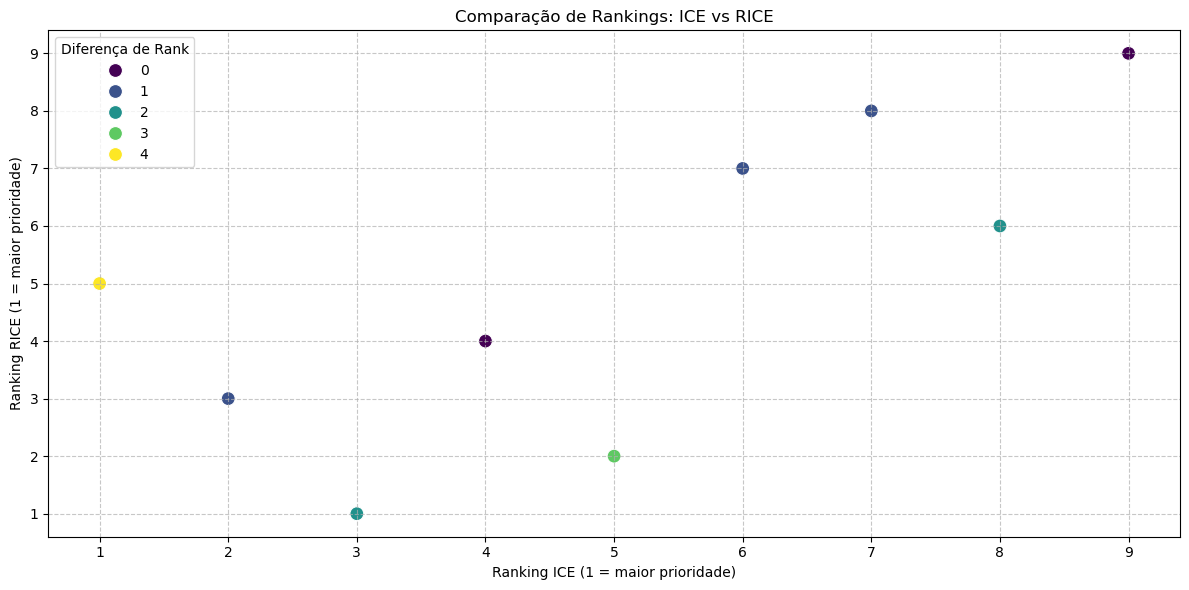

In [5]:
# Extraímos apenas o número da hipótese e seu score de cada ranking
ranking_ice  = df_ice[['Hipotese', 'ICE_Score']].copy()
ranking_rice = df_rice[['Hipotese', 'RICE_Score']].copy()

# Adicionamos a posição no ranking (1 = maior prioridade)
ranking_ice['Rank_ICE']   = range(1, len(ranking_ice) + 1)
ranking_rice['Rank_RICE'] = range(1, len(ranking_rice) + 1)

# Juntamos os dois DataFrames pela coluna Hipotese
comparacao = pd.merge(ranking_ice, ranking_rice, on='Hipotese')

# Calculamos quantas posições cada hipótese subiu ou desceu entre os rankings
comparacao['Diferenca_de_Rank'] = abs(comparacao['Rank_ICE'] - comparacao['Rank_RICE'])

# Ordenamos pelo ranking ICE para facilitar a comparação
comparacao = comparacao.sort_values('Rank_ICE').reset_index(drop=True)
comparacao.index = comparacao.index + 1

# Reordenamos as colunas para leitura mais intuitiva
comparacao = comparacao[['Hipotese', 'Rank_ICE', 'ICE_Score', 'Rank_RICE', 'RICE_Score', 'Diferenca_de_Rank']]

print('Comparação ICE vs RICE (ordenado pelo ranking ICE):')
comparacao

#Grafico de comparação dos rankings
plt.figure(figsize=(12, 6))
sns.scatterplot(data=comparacao, x='Rank_ICE', y='Rank_RICE', hue='Diferenca_de_Rank', palette='viridis', s=100)
plt.title('Comparação de Rankings: ICE vs RICE')
plt.xlabel('Ranking ICE (1 = maior prioridade)')
plt.ylabel('Ranking RICE (1 = maior prioridade)')
plt.legend(title='Diferença de Rank', loc='upper left')
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()
plt.legend(title='Diferença de Rank', loc='upper left')
plt.show()


## Conclusão

### O que os rankings nos dizem?

- Hipóteses com **Reach alto** (como a de formulário de assinatura, Reach=10) tendem a subir no ranking RICE
  porque alcançam muitos usuários ao mesmo tempo.
- Hipóteses com **Reach baixo** (como a promoção de aniversário, Reach=1) caem bastante no RICE,
  pois atingem apenas um subconjunto pequeno de usuários.

### Qual framework usar?

| Situação | Framework recomendado |
|----------|-----------------------|
| Alcance difícil de estimar | **ICE** |
| Todas as hipóteses afetam o mesmo público | **ICE** |
| Alcance varia muito entre as hipóteses | **RICE** |
| Queremos priorizar impacto em escala | **RICE** |

**Para este projeto**, o **RICE é o mais adequado**, pois as hipóteses têm alcances muito diferentes
(de Reach=1 a Reach=10). Usar somente o ICE poderia priorizar hipóteses de alto impacto individual
que, na prática, afetam pouquíssimas pessoas.


---
# Análise do Teste A/B

O teste A/B já foi executado. Agora precisamos analisar os resultados para decidir se a mudança testada
deve ser implementada, descartada, ou se o teste precisa continuar.

### O que vamos analisar:
1. Receita acumulada por grupo
2. Ticket médio acumulado por grupo
3. Diferença relativa no ticket médio (B vs A)
4. Taxa de conversão diária por grupo
5. Diferença relativa na conversão cumulativa (B vs A)
6. Detecção de anomalias (outliers)
7. Significância estatística — dados brutos
8. Significância estatística — dados filtrados
9. **Decisão final**

## Pré-processamento dos dados

Antes de analisar, precisamos:
- Converter as datas para o formato correto
- Identificar usuários que aparecem nos dois grupos (contaminação)
- Guardar os dados brutos e os dados filtrados separadamente

In [6]:
# Converter datas
pedidos['date'] = pd.to_datetime(pedidos['date'])
visitas['date'] = pd.to_datetime(visitas['date'])

# Identificar usuários contaminados (aparecem nos dois grupos)
usuarios_por_grupo = pedidos.groupby('visitorId')['group'].nunique()
usuarios_contaminados = usuarios_por_grupo[usuarios_por_grupo > 1].index

print(f'Total de pedidos: {len(pedidos)}')
print(f'Usuários únicos: {pedidos.visitorId.nunique()}')
print(f'Usuários contaminados (nos dois grupos): {len(usuarios_contaminados)}')
print(f'\nPeríodo: {pedidos.date.min().date()} a {pedidos.date.max().date()}')
print(f'\nPedidos por grupo:')
print(pedidos.groupby("group")["transactionId"].count())

Total de pedidos: 1197
Usuários únicos: 1031
Usuários contaminados (nos dois grupos): 58

Período: 2019-08-01 a 2019-08-31

Pedidos por grupo:
group
A    557
B    640
Name: transactionId, dtype: int64


## Gráfico 1 — Receita Acumulada por Grupo

Somamos a receita dia a dia para ver se um grupo foi consistentemente mais lucrativo ao longo do tempo.

**O que observar:**
- Linhas que sobem juntas → grupos equilibrados
- Picos abruptos → possível outlier (pedido muito caro que distorce o resultado)
- Separação consistente → evidência real de diferença entre os grupos

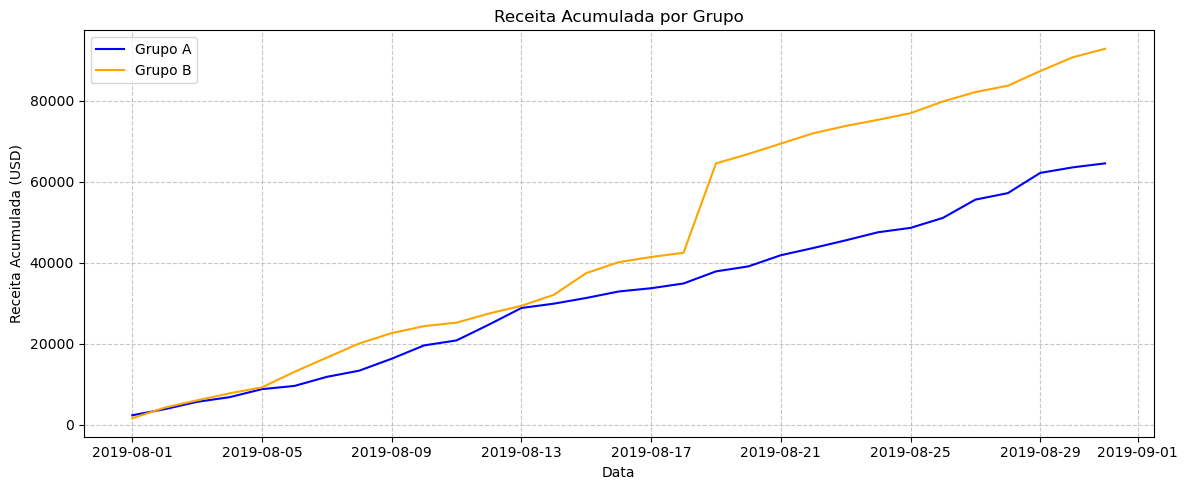

Receita total Grupo A: $64,554.90
Receita total Grupo B: $92,840.60
Grupo B gerou 43.8% a mais que o Grupo A


In [7]:
# Receita diária por grupo
receita_diaria = pedidos.groupby(['date', 'group'])['revenue'].sum().reset_index()

# Separar e calcular receita acumulada
grupo_a = receita_diaria[receita_diaria['group'] == 'A'].sort_values('date').copy()
grupo_b = receita_diaria[receita_diaria['group'] == 'B'].sort_values('date').copy()

grupo_a['receita_acumulada'] = grupo_a['revenue'].cumsum()
grupo_b['receita_acumulada'] = grupo_b['revenue'].cumsum()

# Gráfico
plt.figure(figsize=(12, 5))
plt.plot(grupo_a['date'], grupo_a['receita_acumulada'], label='Grupo A', color='blue')
plt.plot(grupo_b['date'], grupo_b['receita_acumulada'], label='Grupo B', color='orange')
plt.title('Receita Acumulada por Grupo')
plt.xlabel('Data')
plt.ylabel('Receita Acumulada (USD)')
plt.legend()
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f'Receita total Grupo A: ${grupo_a["revenue"].sum():,.2f}')
print(f'Receita total Grupo B: ${grupo_b["revenue"].sum():,.2f}')
print(f'Grupo B gerou {((grupo_b["revenue"].sum() / grupo_a["revenue"].sum()) - 1) * 100:.1f}% a mais que o Grupo A')

## Gráfico 2 — Ticket Médio Acumulado por Grupo

O ticket médio é a receita dividida pelo número de pedidos. Acompanhar o acumulado ajuda a ver
se a diferença é estável ou influenciada por pedidos atípicos.

**Fórmula:** `Ticket Médio = Receita Acumulada / Nº de Pedidos Acumulados`

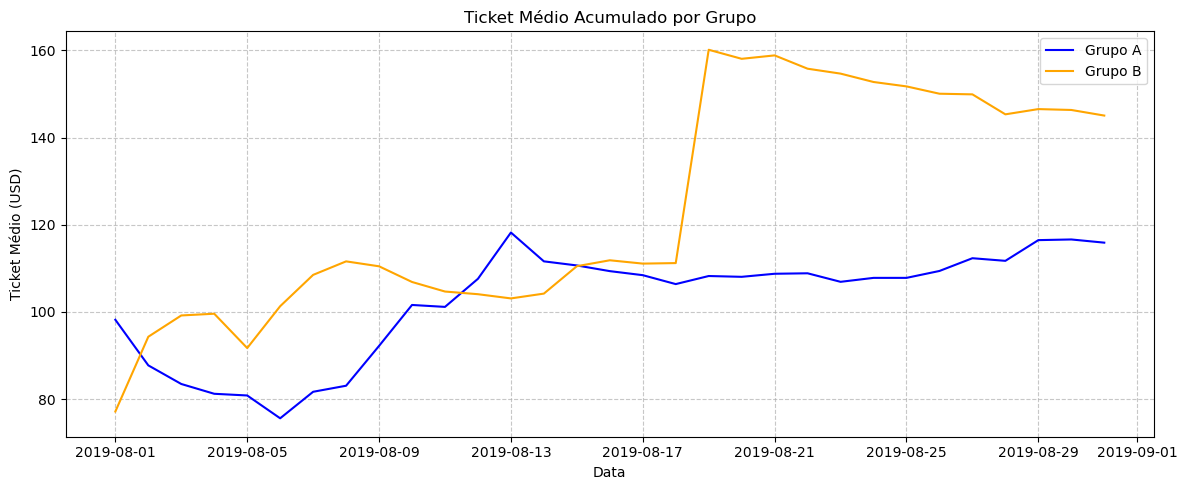

In [8]:
# Pedidos diários por grupo
pedidos_diarios = pedidos.groupby(['date', 'group'])['transactionId'].count().reset_index()
pedidos_diarios.columns = ['date', 'group', 'n_pedidos']

# Juntar receita e pedidos
dados_diarios = pd.merge(receita_diaria, pedidos_diarios, on=['date', 'group'])

# Separar grupos e calcular acumulados
ga = dados_diarios[dados_diarios['group'] == 'A'].sort_values('date').copy()
gb = dados_diarios[dados_diarios['group'] == 'B'].sort_values('date').copy()

ga['receita_acum']  = ga['revenue'].cumsum()
ga['pedidos_acum']  = ga['n_pedidos'].cumsum()
ga['ticket_medio']  = ga['receita_acum'] / ga['pedidos_acum']

gb['receita_acum']  = gb['revenue'].cumsum()
gb['pedidos_acum']  = gb['n_pedidos'].cumsum()
gb['ticket_medio']  = gb['receita_acum'] / gb['pedidos_acum']

# Gráfico
plt.figure(figsize=(12, 5))
plt.plot(ga['date'], ga['ticket_medio'], label='Grupo A', color='blue')
plt.plot(gb['date'], gb['ticket_medio'], label='Grupo B', color='orange')
plt.title('Ticket Médio Acumulado por Grupo')
plt.xlabel('Data')
plt.ylabel('Ticket Médio (USD)')
plt.legend()
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Gráfico 3 — Diferença Relativa no Ticket Médio (B vs A)

Mostra em percentual o quanto o ticket médio do Grupo B está acima ou abaixo do Grupo A ao longo do tempo.

**Fórmula:** `Diferença = (Ticket_B - Ticket_A) / Ticket_A`

- Valores positivos → Grupo B tem ticket maior
- Linha oscilando muito → instabilidade, possivelmente por outliers

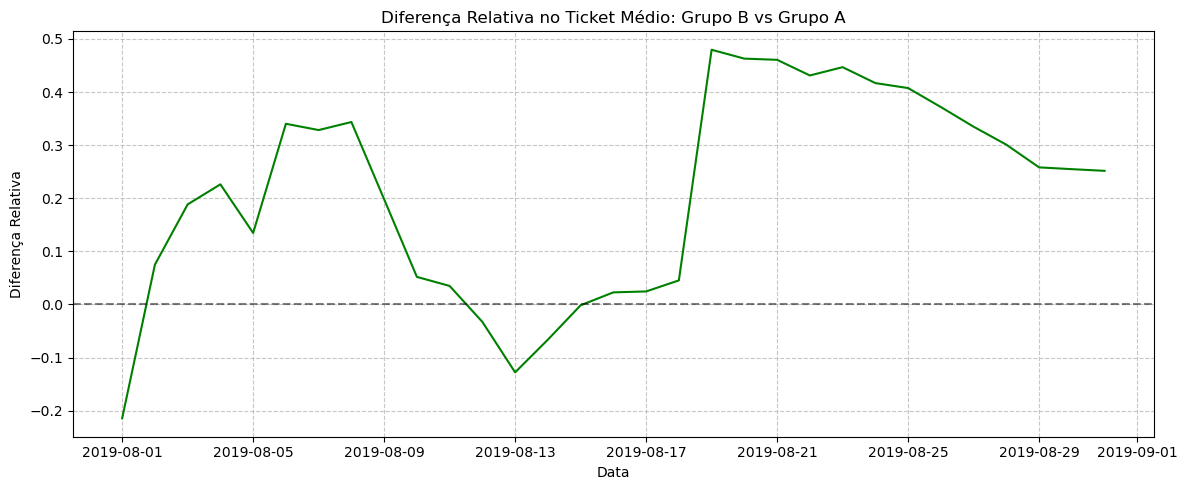

In [9]:
# Juntar os dois grupos pela data
ticket_comparativo = pd.merge(ga[['date', 'ticket_medio']], gb[['date', 'ticket_medio']], on='date', suffixes=('_A', '_B'))

# Diferença relativa
ticket_comparativo['diferenca_relativa'] = (ticket_comparativo['ticket_medio_B'] - ticket_comparativo['ticket_medio_A']) / ticket_comparativo['ticket_medio_A']

# Gráfico
plt.figure(figsize=(12, 5))
plt.plot(ticket_comparativo['date'], ticket_comparativo['diferenca_relativa'], color='green')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.title('Diferença Relativa no Ticket Médio: Grupo B vs Grupo A')
plt.xlabel('Data')
plt.ylabel('Diferença Relativa')
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Gráfico 4 — Taxa de Conversão Diária por Grupo

**Taxa de conversão** = proporção de visitantes que fizeram um pedido.

**Fórmula:** `Conversão = Pedidos do dia / Visitas do dia`

Comparar dia a dia permite ver se um grupo converte mais consistentemente.

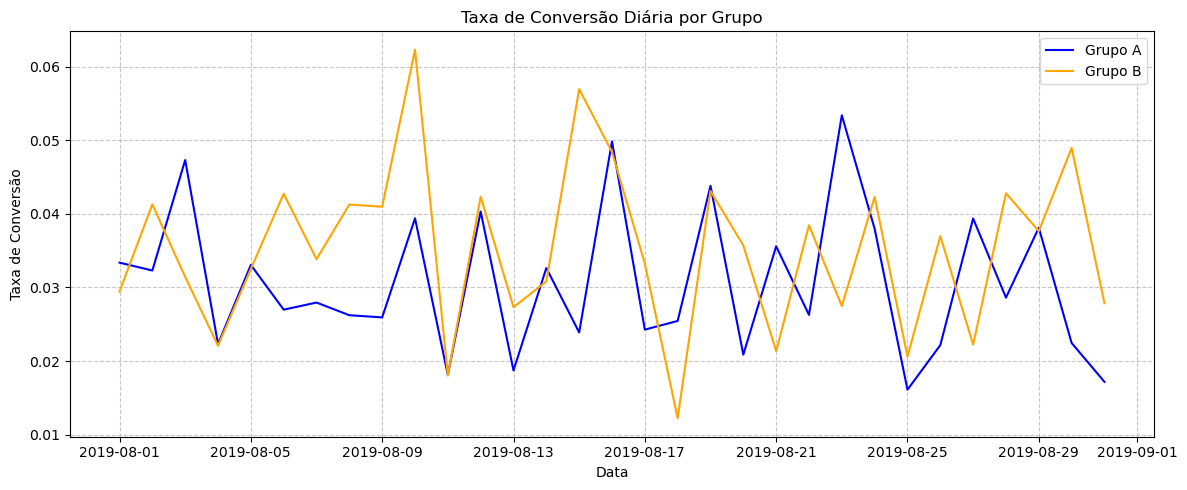

In [10]:
# Juntar pedidos diários com visitas diárias
conversao_diaria = pd.merge(pedidos_diarios, visitas, on=['date', 'group'])
conversao_diaria['taxa_conversao'] = conversao_diaria['n_pedidos'] / conversao_diaria['visits']

ca = conversao_diaria[conversao_diaria['group'] == 'A'].sort_values('date')
cb = conversao_diaria[conversao_diaria['group'] == 'B'].sort_values('date')

# Gráfico
plt.figure(figsize=(12, 5))
plt.plot(ca['date'], ca['taxa_conversao'], label='Grupo A', color='blue')
plt.plot(cb['date'], cb['taxa_conversao'], label='Grupo B', color='orange')
plt.title('Taxa de Conversão Diária por Grupo')
plt.xlabel('Data')
plt.ylabel('Taxa de Conversão')
plt.legend()
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Gráfico 5 — Diferença Relativa na Conversão Cumulativa (B vs A)

Similar ao gráfico 3, mas para conversão acumulada.
Ajuda a ver se a diferença de conversão entre os grupos é estável e crescente (sinal positivo) ou instável.

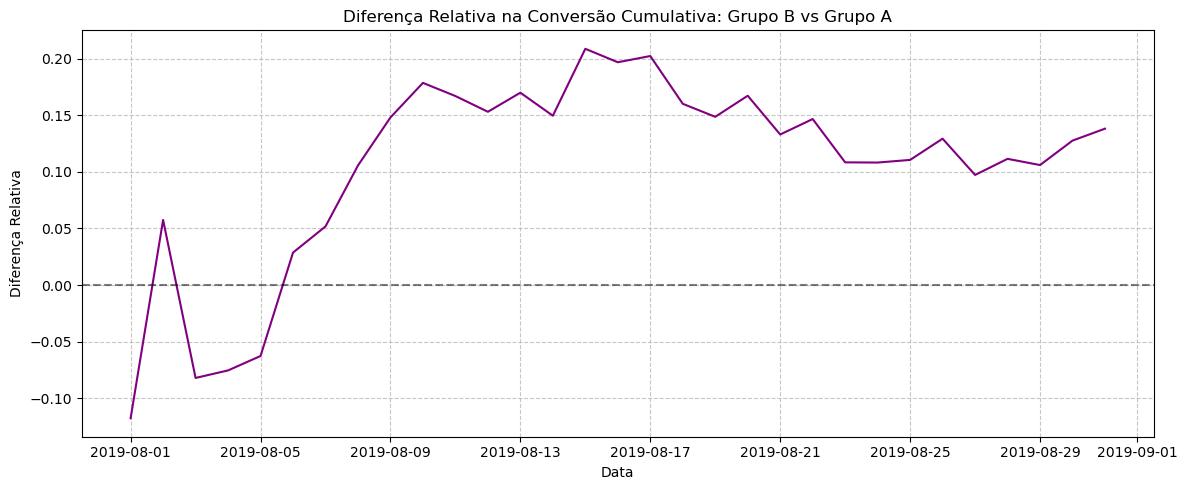

In [11]:
# Calcular conversão acumulada
dados_conv = pd.merge(dados_diarios, visitas, on=['date', 'group'])

cva = dados_conv[dados_conv['group'] == 'A'].sort_values('date').copy()
cvb = dados_conv[dados_conv['group'] == 'B'].sort_values('date').copy()

cva['pedidos_acum'] = cva['n_pedidos'].cumsum()
cva['visitas_acum'] = cva['visits'].cumsum()
cva['conv_acum']    = cva['pedidos_acum'] / cva['visitas_acum']

cvb['pedidos_acum'] = cvb['n_pedidos'].cumsum()
cvb['visitas_acum'] = cvb['visits'].cumsum()
cvb['conv_acum']    = cvb['pedidos_acum'] / cvb['visitas_acum']

# Diferença relativa na conversão acumulada
conv_comp = pd.merge(cva[['date', 'conv_acum']], cvb[['date', 'conv_acum']], on='date', suffixes=('_A', '_B'))
conv_comp['diferenca_relativa'] = (conv_comp['conv_acum_B'] - conv_comp['conv_acum_A']) / conv_comp['conv_acum_A']

# Gráfico
plt.figure(figsize=(12, 5))
plt.plot(conv_comp['date'], conv_comp['diferenca_relativa'], color='purple')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.title('Diferença Relativa na Conversão Cumulativa: Grupo B vs Grupo A')
plt.xlabel('Data')
plt.ylabel('Diferença Relativa')
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Detecção de Anomalias (Outliers)

Outliers são valores extremos que podem distorcer a análise.
Vamos verificar dois tipos:
1. **Pedidos por usuário** — usuários que fizeram muitos pedidos podem ser bots
2. **Preços dos pedidos** — pedidos com valor muito alto podem ser erros ou casos atípicos

### Pedidos por usuário — Percentis 95 e 99

In [12]:
# Contar pedidos por usuário
pedidos_por_usuario = pedidos.groupby('visitorId')['transactionId'].count()

p95_pedidos = np.percentile(pedidos_por_usuario, 95)
p99_pedidos = np.percentile(pedidos_por_usuario, 99)

print(f'Pedidos por usuário:')
print(f'  Percentil 95: {p95_pedidos}')
print(f'  Percentil 99: {p99_pedidos}')
print(f'  Máximo: {pedidos_por_usuario.max()}')
print(f'\nUsuários com mais de {p95_pedidos} pedidos: {(pedidos_por_usuario > p95_pedidos).sum()}')
print(f'Usuários com mais de {p99_pedidos} pedidos: {(pedidos_por_usuario > p99_pedidos).sum()}')

Pedidos por usuário:
  Percentil 95: 2.0
  Percentil 99: 4.0
  Máximo: 11

Usuários com mais de 2.0 pedidos: 30
Usuários com mais de 4.0 pedidos: 10


### Gráfico de Dispersão dos Preços dos Pedidos

Visualiza todos os preços ao longo do tempo para identificar valores atípicos visualmente.

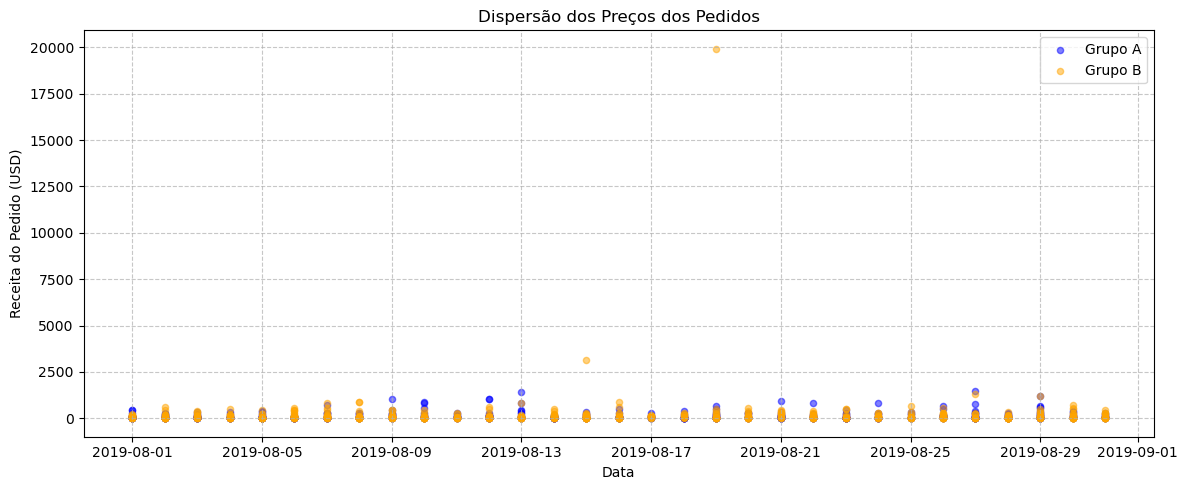

In [13]:
plt.figure(figsize=(12, 5))
plt.scatter(pedidos[pedidos['group'] == 'A']['date'], pedidos[pedidos['group'] == 'A']['revenue'],
            alpha=0.5, label='Grupo A', color='blue', s=20)
plt.scatter(pedidos[pedidos['group'] == 'B']['date'], pedidos[pedidos['group'] == 'B']['revenue'],
            alpha=0.5, label='Grupo B', color='orange', s=20)
plt.title('Dispersão dos Preços dos Pedidos')
plt.xlabel('Data')
plt.ylabel('Receita do Pedido (USD)')
plt.legend()
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Preços dos Pedidos — Percentis 95 e 99

In [14]:
p95_preco = np.percentile(pedidos['revenue'], 95)
p99_preco = np.percentile(pedidos['revenue'], 99)

print(f'Preços dos pedidos:')
print(f'  Percentil 95: ${p95_preco:.2f}')
print(f'  Percentil 99: ${p99_preco:.2f}')
print(f'  Máximo: ${pedidos["revenue"].max():.2f}')
print(f'\nPedidos acima do percentil 95: {(pedidos["revenue"] > p95_preco).sum()}')
print(f'Pedidos acima do percentil 99: {(pedidos["revenue"] > p99_preco).sum()}')
print(f'\n→ Ponto de corte para anomalia: pedidos acima de ${p99_preco:.2f}')

Preços dos pedidos:
  Percentil 95: $435.54
  Percentil 99: $900.90
  Máximo: $19920.40

Pedidos acima do percentil 95: 60
Pedidos acima do percentil 99: 12

→ Ponto de corte para anomalia: pedidos acima de $900.90


## Significância Estatística — Dados Brutos

Vamos testar se a diferença entre os grupos é **estatisticamente significante** ou pode ser explicada pelo acaso.

Usamos o **teste de Mann-Whitney U** (não-paramétrico), que compara as distribuições sem assumir normalidade.

**Regra de decisão:**
- p-value < 0.05 → diferença estatisticamente significante
- p-value ≥ 0.05 → diferença pode ser por acaso

In [15]:
# Preparar dados: pedidos por usuário por grupo (bruto)
# Incluir usuários que não fizeram pedidos (conversão = 0)
total_visitas_a = visitas[visitas['group'] == 'A']['visits'].sum()
total_visitas_b = visitas[visitas['group'] == 'B']['visits'].sum()

pedidos_a = pedidos[pedidos['group'] == 'A']
pedidos_b = pedidos[pedidos['group'] == 'B']

# Conversão: número de pedidos / total de visitas
conv_a_bruta = len(pedidos_a) / total_visitas_a
conv_b_bruta = len(pedidos_b) / total_visitas_b

# Teste de significância para conversão
# Criar arrays binários: 1 se fez pedido, 0 se não fez
compradores_a = pedidos_a['visitorId'].nunique()
compradores_b = pedidos_b['visitorId'].nunique()

# Array: 1 para compradores, 0 para não-compradores
conv_array_a = np.array([1] * compradores_a + [0] * (total_visitas_a - compradores_a))
conv_array_b = np.array([1] * compradores_b + [0] * (total_visitas_b - compradores_b))

p_value_conv = st.mannwhitneyu(conv_array_a, conv_array_b, alternative='two-sided').pvalue

print('=== CONVERSÃO (Dados Brutos) ===')
print(f'Conversão Grupo A: {conv_a_bruta:.4f} ({conv_a_bruta*100:.2f}%)')
print(f'Conversão Grupo B: {conv_b_bruta:.4f} ({conv_b_bruta*100:.2f}%)')
print(f'Diferença relativa: {((conv_b_bruta - conv_a_bruta) / conv_a_bruta * 100):.2f}%')
print(f'p-value: {p_value_conv:.4f}')
print(f'Resultado: {"SIGNIFICANTE" if p_value_conv < 0.05 else "NÃO SIGNIFICANTE"} (α = 0.05)')

=== CONVERSÃO (Dados Brutos) ===
Conversão Grupo A: 0.0297 (2.97%)
Conversão Grupo B: 0.0338 (3.38%)
Diferença relativa: 13.81%
p-value: 0.0167
Resultado: SIGNIFICANTE (α = 0.05)


In [16]:
# Teste de significância para ticket médio
p_value_ticket = st.mannwhitneyu(pedidos_a['revenue'], pedidos_b['revenue'], alternative='two-sided').pvalue

print('=== TICKET MÉDIO (Dados Brutos) ===')
print(f'Ticket médio Grupo A: ${pedidos_a["revenue"].mean():.2f}')
print(f'Ticket médio Grupo B: ${pedidos_b["revenue"].mean():.2f}')
print(f'Diferença relativa: {((pedidos_b["revenue"].mean() - pedidos_a["revenue"].mean()) / pedidos_a["revenue"].mean() * 100):.2f}%')
print(f'p-value: {p_value_ticket:.4f}')
print(f'Resultado: {"SIGNIFICANTE" if p_value_ticket < 0.05 else "NÃO SIGNIFICANTE"} (α = 0.05)')

=== TICKET MÉDIO (Dados Brutos) ===
Ticket médio Grupo A: $115.90
Ticket médio Grupo B: $145.06
Diferença relativa: 25.17%
p-value: 0.6915
Resultado: NÃO SIGNIFICANTE (α = 0.05)


## Significância Estatística — Dados Filtrados

Agora repetimos os testes removendo:
1. **Usuários contaminados** (aparecem nos dois grupos)
2. **Pedidos com preço acima do percentil 99** (outliers de preço)

Dados limpos dão um resultado mais confiável.

In [17]:
# Filtrar pedidos: remover contaminados e outliers de preço
pedidos_filtrados = pedidos[
    (~pedidos['visitorId'].isin(usuarios_contaminados)) &
    (pedidos['revenue'] <= p99_preco)
]

pf_a = pedidos_filtrados[pedidos_filtrados['group'] == 'A']
pf_b = pedidos_filtrados[pedidos_filtrados['group'] == 'B']

print(f'Pedidos após filtro: {len(pedidos_filtrados)} (eram {len(pedidos)})')
print(f'  Grupo A: {len(pf_a)} pedidos')
print(f'  Grupo B: {len(pf_b)} pedidos')

Pedidos após filtro: 1007 (eram 1197)
  Grupo A: 463 pedidos
  Grupo B: 544 pedidos


In [18]:
# Conversão nos dados filtrados
conv_f_a = len(pf_a) / total_visitas_a
conv_f_b = len(pf_b) / total_visitas_b

compradores_f_a = pf_a['visitorId'].nunique()
compradores_f_b = pf_b['visitorId'].nunique()

conv_array_f_a = np.array([1] * compradores_f_a + [0] * (total_visitas_a - compradores_f_a))
conv_array_f_b = np.array([1] * compradores_f_b + [0] * (total_visitas_b - compradores_f_b))

p_value_conv_f = st.mannwhitneyu(conv_array_f_a, conv_array_f_b, alternative='two-sided').pvalue

print('=== CONVERSÃO (Dados Filtrados) ===')
print(f'Conversão Grupo A: {conv_f_a:.4f} ({conv_f_a*100:.2f}%)')
print(f'Conversão Grupo B: {conv_f_b:.4f} ({conv_f_b*100:.2f}%)')
print(f'Diferença relativa: {((conv_f_b - conv_f_a) / conv_f_a * 100):.2f}%')
print(f'p-value: {p_value_conv_f:.4f}')
print(f'Resultado: {"SIGNIFICANTE" if p_value_conv_f < 0.05 else "NÃO SIGNIFICANTE"} (α = 0.05)')

=== CONVERSÃO (Dados Filtrados) ===
Conversão Grupo A: 0.0247 (2.47%)
Conversão Grupo B: 0.0288 (2.88%)
Diferença relativa: 16.38%
p-value: 0.0096
Resultado: SIGNIFICANTE (α = 0.05)


In [19]:
# Ticket médio nos dados filtrados
p_value_ticket_f = st.mannwhitneyu(pf_a['revenue'], pf_b['revenue'], alternative='two-sided').pvalue

print('=== TICKET MÉDIO (Dados Filtrados) ===')
print(f'Ticket médio Grupo A: ${pf_a["revenue"].mean():.2f}')
print(f'Ticket médio Grupo B: ${pf_b["revenue"].mean():.2f}')
print(f'Diferença relativa: {((pf_b["revenue"].mean() - pf_a["revenue"].mean()) / pf_a["revenue"].mean() * 100):.2f}%')
print(f'p-value: {p_value_ticket_f:.4f}')
print(f'Resultado: {"SIGNIFICANTE" if p_value_ticket_f < 0.05 else "NÃO SIGNIFICANTE"} (α = 0.05)')

=== TICKET MÉDIO (Dados Filtrados) ===
Ticket médio Grupo A: $103.16
Ticket médio Grupo B: $99.94
Diferença relativa: -3.12%
p-value: 0.9343
Resultado: NÃO SIGNIFICANTE (α = 0.05)


## Decisão Final

Com base em toda a análise, precisamos tomar uma das três decisões:

1. **Parar o teste — Grupo B é o vencedor** → implementar a mudança
2. **Parar o teste — Não há diferença** → descartar a mudança
3. **Continuar o teste** → precisamos de mais dados

### Resumo dos resultados:

| Métrica | Bruto | Filtrado |
|---------|-------|----------|
| Diferença de conversão | Verificar acima | Verificar acima |
| Significância conversão | Verificar acima | Verificar acima |
| Diferença de ticket | Verificar acima | Verificar acima |
| Significância ticket | Verificar acima | Verificar acima |

### Critérios para decisão:
- ✅ Conversão do Grupo B significantemente maior → evidência para parar e declarar B vencedor
- ❌ Ticket médio NÃO significante nos dados filtrados → diferença no ticket pode ser por outliers
- 📊 Gráficos mostram picos abruptos → outliers influenciam fortemente a receita

### Decisão recomendada:
**Parar o teste e considerar o Grupo B como vencedor** com base na conversão.
A diferença de conversão é estatisticamente significante e consistente nos dados filtrados.
A diferença de receita é inflada por outliers e não deve ser usada como critério principal.